# Logical noise metrology for Gemini logical kernels

This notebook implements several logical-noise-metrology workflows at the user level, using `@logical.kernel` programs compiled through `GeminiLogicalSimulator`.

The implementations below cover five practical paradigms:

1. decode-first logical Pauli-rate estimation
2. benchmarking-style logical survival experiments
3. reduced logical process tomography
4. cycle-level effective transition models
5. a lightweight model-fitting / learning-style analysis

A syndrome-conditioned analysis helper is also included because it is often the most immediately useful debug view when logical error rates are unexpectedly high.


In [1]:
from __future__ import annotations

from collections import Counter, defaultdict
from time import perf_counter
from typing import Any, Callable

import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt

from bloqade import qubit, squin
from bloqade.gemini import logical
from bloqade.lanes import GeminiLogicalSimulator
from bloqade.decoders import BpOsdDecoder, BpLsdDecoder, BaseDecoder


DecoderCtor = Callable[[Any], BaseDecoder]
sim = GeminiLogicalSimulator()


In [2]:
def _run_task(kernel, shots: int = 4000, *, with_noise: bool = True):
    task = sim.task(kernel)
    result = task.run(shots, with_noise=with_noise)
    detectors = np.asarray(result.detectors, dtype=bool)
    observables = np.asarray(result.observables, dtype=bool)
    return task, result, detectors, observables


def _reference_target(task, kernel, reference_shots: int = 512) -> npt.NDArray[np.bool_]:
    result = task.run(reference_shots, with_noise=False)
    observables = np.asarray(result.observables, dtype=bool)
    counts = Counter(map(lambda row: tuple(map(int, row)), observables.tolist()))
    target, _ = counts.most_common(1)[0]
    return np.asarray(target, dtype=bool)


def _decode_observables(
    task,
    detectors: npt.NDArray[np.bool_],
    observables: npt.NDArray[np.bool_],
    decoder_ctor: DecoderCtor,
) -> tuple[npt.NDArray[np.bool_], npt.NDArray[np.bool_]]:
    decoder = decoder_ctor(task.detector_error_model)
    flips = np.asarray(decoder.decode(detectors), dtype=bool)
    corrected = observables ^ flips
    return flips, corrected


def _logical_error_rate(corrected: npt.NDArray[np.bool_], target: npt.NDArray[np.bool_]) -> float:
    target_rows = np.broadcast_to(target, corrected.shape)
    failures = np.any(corrected != target_rows, axis=1)
    return float(np.mean(failures))


def _observable_expectation(corrected: npt.NDArray[np.bool_]) -> float:
    if corrected.ndim != 2 or corrected.shape[1] != 1:
        raise ValueError("This helper expects a single logical observable bit.")
    bit_values = corrected[:, 0].astype(float)
    return float(np.mean(1.0 - 2.0 * bit_values))


def _plot_matrix(matrix: npt.NDArray[np.float64], title: str, row_labels: list[str], col_labels: list[str], cmap: str = "RdBu_r"):
    fig, ax = plt.subplots(figsize=(5, 4))
    image = ax.imshow(matrix, cmap=cmap, vmin=np.min(matrix), vmax=np.max(matrix))
    ax.set_title(title)
    ax.set_xticks(range(len(col_labels)), labels=col_labels)
    ax.set_yticks(range(len(row_labels)), labels=row_labels)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(j, i, f"{matrix[i, j]:.3f}", ha="center", va="center")
    fig.colorbar(image, ax=ax, shrink=0.8)
    plt.tight_layout()
    plt.show()


## Probe kernels

All kernels here are written directly in the `@logical.kernel` dialect and use `logical.default_post_processing(reg)` to produce detector and logical-observable information.

The three basis-preservation probes are the core building blocks for the metrology helpers below.


In [3]:
@logical.kernel(aggressive_unroll=True, verify=True)
def z_memory_probe():
    reg = qubit.qalloc(1)
    logical.default_post_processing(reg)


@logical.kernel(aggressive_unroll=True, verify=True)
def x_memory_probe():
    reg = qubit.qalloc(1)
    squin.h(reg[0])
    squin.h(reg[0])
    logical.default_post_processing(reg)


@logical.kernel(aggressive_unroll=True, verify=True)
def y_memory_probe():
    reg = qubit.qalloc(1)
    squin.sqrt_x(reg[0])
    squin.sqrt_x_adj(reg[0])
    logical.default_post_processing(reg)


@logical.kernel(aggressive_unroll=True, verify=True)
def tomo_z_meas_z():
    reg = qubit.qalloc(1)
    logical.default_post_processing(reg)


@logical.kernel(aggressive_unroll=True, verify=True)
def tomo_z_meas_x():
    reg = qubit.qalloc(1)
    squin.h(reg[0])
    logical.default_post_processing(reg)


@logical.kernel(aggressive_unroll=True, verify=True)
def tomo_z_meas_y():
    reg = qubit.qalloc(1)
    squin.sqrt_x_adj(reg[0])
    logical.default_post_processing(reg)


@logical.kernel(aggressive_unroll=True, verify=True)
def tomo_x_meas_z():
    reg = qubit.qalloc(1)
    squin.h(reg[0])
    logical.default_post_processing(reg)


@logical.kernel(aggressive_unroll=True, verify=True)
def tomo_x_meas_x():
    reg = qubit.qalloc(1)
    squin.h(reg[0])
    squin.h(reg[0])
    logical.default_post_processing(reg)


@logical.kernel(aggressive_unroll=True, verify=True)
def tomo_x_meas_y():
    reg = qubit.qalloc(1)
    squin.h(reg[0])
    squin.sqrt_x_adj(reg[0])
    logical.default_post_processing(reg)


@logical.kernel(aggressive_unroll=True, verify=True)
def tomo_y_meas_z():
    reg = qubit.qalloc(1)
    squin.sqrt_x(reg[0])
    logical.default_post_processing(reg)


@logical.kernel(aggressive_unroll=True, verify=True)
def tomo_y_meas_x():
    reg = qubit.qalloc(1)
    squin.sqrt_x(reg[0])
    squin.h(reg[0])
    logical.default_post_processing(reg)


@logical.kernel(aggressive_unroll=True, verify=True)
def tomo_y_meas_y():
    reg = qubit.qalloc(1)
    squin.sqrt_x(reg[0])
    squin.sqrt_x_adj(reg[0])
    logical.default_post_processing(reg)


@logical.kernel(aggressive_unroll=True, verify=True)
def rb_depth_0():
    reg = qubit.qalloc(1)
    logical.default_post_processing(reg)


@logical.kernel(aggressive_unroll=True, verify=True)
def rb_depth_1():
    reg = qubit.qalloc(1)
    squin.h(reg[0])
    squin.h(reg[0])
    logical.default_post_processing(reg)


@logical.kernel(aggressive_unroll=True, verify=True)
def rb_depth_2():
    reg = qubit.qalloc(1)
    squin.h(reg[0])
    squin.h(reg[0])
    squin.z(reg[0])
    squin.z(reg[0])
    logical.default_post_processing(reg)


@logical.kernel(aggressive_unroll=True, verify=True)
def rb_depth_4():
    reg = qubit.qalloc(1)
    squin.h(reg[0])
    squin.h(reg[0])
    squin.z(reg[0])
    squin.z(reg[0])
    squin.h(reg[0])
    squin.h(reg[0])
    squin.z(reg[0])
    squin.z(reg[0])
    logical.default_post_processing(reg)


@logical.kernel(aggressive_unroll=True, verify=True)
def rb_depth_8():
    reg = qubit.qalloc(1)
    squin.h(reg[0])
    squin.h(reg[0])
    squin.z(reg[0])
    squin.z(reg[0])
    squin.h(reg[0])
    squin.h(reg[0])
    squin.z(reg[0])
    squin.z(reg[0])
    squin.h(reg[0])
    squin.h(reg[0])
    squin.z(reg[0])
    squin.z(reg[0])
    squin.h(reg[0])
    squin.h(reg[0])
    squin.z(reg[0])
    squin.z(reg[0])
    logical.default_post_processing(reg)


@logical.kernel(aggressive_unroll=True, verify=True)
def cycle_zero_depth_1():
    reg = qubit.qalloc(1)
    squin.h(reg[0])
    squin.h(reg[0])
    logical.default_post_processing(reg)


@logical.kernel(aggressive_unroll=True, verify=True)
def cycle_zero_depth_2():
    reg = qubit.qalloc(1)
    squin.h(reg[0])
    squin.h(reg[0])
    squin.z(reg[0])
    squin.z(reg[0])
    logical.default_post_processing(reg)


@logical.kernel(aggressive_unroll=True, verify=True)
def cycle_zero_depth_4():
    reg = qubit.qalloc(1)
    squin.h(reg[0])
    squin.h(reg[0])
    squin.z(reg[0])
    squin.z(reg[0])
    squin.h(reg[0])
    squin.h(reg[0])
    squin.z(reg[0])
    squin.z(reg[0])
    logical.default_post_processing(reg)


@logical.kernel(aggressive_unroll=True, verify=True)
def cycle_one_depth_1():
    reg = qubit.qalloc(1)
    squin.x(reg[0])
    squin.h(reg[0])
    squin.h(reg[0])
    logical.default_post_processing(reg)


@logical.kernel(aggressive_unroll=True, verify=True)
def cycle_one_depth_2():
    reg = qubit.qalloc(1)
    squin.x(reg[0])
    squin.h(reg[0])
    squin.h(reg[0])
    squin.z(reg[0])
    squin.z(reg[0])
    logical.default_post_processing(reg)


@logical.kernel(aggressive_unroll=True, verify=True)
def cycle_one_depth_4():
    reg = qubit.qalloc(1)
    squin.x(reg[0])
    squin.h(reg[0])
    squin.h(reg[0])
    squin.z(reg[0])
    squin.z(reg[0])
    squin.h(reg[0])
    squin.h(reg[0])
    squin.z(reg[0])
    squin.z(reg[0])
    logical.default_post_processing(reg)


## 1. Decode-first logical metrology

This is the QEC-native workflow: run a noisy logical experiment, decode the syndromes, correct the logical observables, and infer effective logical error rates.

For a single logical qubit, we can estimate Pauli-like logical noise rates by probing memory in the Z, X, and Y bases.


In [4]:
def decode_first_logical_pauli_metrology(
    decoder_ctor: DecoderCtor = BpOsdDecoder,
    shots: int = 4000,
) -> dict[str, Any]:
    basis_kernels = {
        "Z": z_memory_probe,
        "X": x_memory_probe,
        "Y": y_memory_probe,
    }
    basis_error_rates: dict[str, float] = {}
    postselection_rates: dict[str, float] = {}
    avg_flip_weights: dict[str, float] = {}

    for axis, kernel in basis_kernels.items():
        task, result, detectors, observables = _run_task(kernel, shots, with_noise=True)
        target = _reference_target(task, kernel)
        flips, corrected = _decode_observables(task, detectors, observables, decoder_ctor)
        basis_error_rates[axis] = _logical_error_rate(corrected, target)
        postselection_rates[axis] = float(np.mean(np.all(detectors == 0, axis=1)))
        avg_flip_weights[axis] = float(np.mean(np.sum(flips, axis=1)))

    e_z = basis_error_rates["Z"]
    e_x = basis_error_rates["X"]
    e_y = basis_error_rates["Y"]

    pauli_rates = {
        "pX": max(0.0, 0.5 * (e_z + e_y - e_x)),
        "pY": max(0.0, 0.5 * (e_z + e_x - e_y)),
        "pZ": max(0.0, 0.5 * (e_x + e_y - e_z)),
    }

    return {
        "basis_error_rates": basis_error_rates,
        "estimated_logical_pauli_rates": pauli_rates,
        "postselection_rates": postselection_rates,
        "average_flip_weights": avg_flip_weights,
    }


decode_first_results = decode_first_logical_pauli_metrology()
decode_first_results


{'basis_error_rates': {'Z': 0.0, 'X': 0.0, 'Y': 0.0},
 'estimated_logical_pauli_rates': {'pX': 0.0, 'pY': 0.0, 'pZ': 0.0},
 'postselection_rates': {'Z': 1.0, 'X': 0.99425, 'Y': 0.9975},
 'average_flip_weights': {'Z': 0.0, 'X': 0.00225, 'Y': 0.00075}}

## 2. Benchmarking-style logical survival experiments

This is a logical-RB-style survival experiment. The kernels below use identity-preserving logical Clifford subcircuits of increasing depth, and we track the survival probability after decoding.


In [5]:
def logical_survival_benchmark(
    decoder_ctor: DecoderCtor = BpOsdDecoder,
    shots: int = 4000,
) -> dict[str, Any]:
    sequence_kernels = {
        0: rb_depth_0,
        1: rb_depth_1,
        2: rb_depth_2,
        4: rb_depth_4,
        8: rb_depth_8,
    }

    depths: list[int] = []
    survival_probabilities: list[float] = []
    logical_error_rates: list[float] = []

    for depth, kernel in sequence_kernels.items():
        task, _, detectors, observables = _run_task(kernel, shots, with_noise=True)
        target = _reference_target(task, kernel)
        _, corrected = _decode_observables(task, detectors, observables, decoder_ctor)
        ler = _logical_error_rate(corrected, target)
        survival = 1.0 - ler
        depths.append(depth)
        logical_error_rates.append(ler)
        survival_probabilities.append(survival)

    safe_survival = np.clip(np.asarray(survival_probabilities), 1e-9, 1.0)
    slope, intercept = np.polyfit(depths, np.log(safe_survival), 1)
    decay_constant = float(np.exp(slope))

    return {
        "depths": depths,
        "survival_probabilities": survival_probabilities,
        "logical_error_rates": logical_error_rates,
        "fit_intercept": float(np.exp(intercept)),
        "decay_constant": decay_constant,
        "logical_error_per_block_proxy": float(1.0 - decay_constant),
    }


rb_results = logical_survival_benchmark()
rb_results


{'depths': [0, 1, 2, 4, 8],
 'survival_probabilities': [1.0, 1.0, 1.0, 1.0, 0.99975],
 'logical_error_rates': [0.0, 0.0, 0.0, 0.0, 0.00025],
 'fit_intercept': 1.0000437564269462,
 'decay_constant': 0.9999687465814971,
 'logical_error_per_block_proxy': 3.125341850285235e-05}

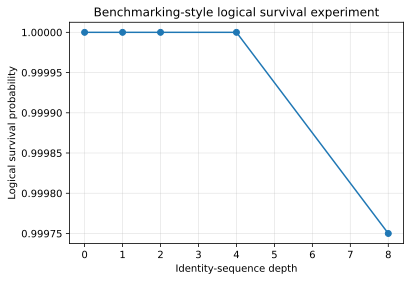

In [6]:
plt.figure(figsize=(6, 4))
plt.plot(rb_results["depths"], rb_results["survival_probabilities"], marker="o")
plt.xlabel("Identity-sequence depth")
plt.ylabel("Logical survival probability")
plt.title("Benchmarking-style logical survival experiment")
plt.grid(True, alpha=0.3)
plt.show()


## 3. Reduced logical process tomography

This is a small-scale, single-logical-qubit tomography routine. It estimates a reduced Bloch-transfer matrix by preparing +Z, +X, and +Y logical states and measuring output expectations in the Z, X, and Y bases after decoding.

This is not full tomography of an arbitrary affine channel, but it is a useful compact debugging view for a small logical system.


In [7]:
def reduced_logical_process_tomography(
    decoder_ctor: DecoderCtor = BpOsdDecoder,
    shots: int = 4000,
) -> dict[str, Any]:
    kernels = {
        ("Z", "Z"): tomo_z_meas_z,
        ("Z", "X"): tomo_z_meas_x,
        ("Z", "Y"): tomo_z_meas_y,
        ("X", "Z"): tomo_x_meas_z,
        ("X", "X"): tomo_x_meas_x,
        ("X", "Y"): tomo_x_meas_y,
        ("Y", "Z"): tomo_y_meas_z,
        ("Y", "X"): tomo_y_meas_x,
        ("Y", "Y"): tomo_y_meas_y,
    }

    prep_axes = ["Z", "X", "Y"]
    meas_axes = ["Z", "X", "Y"]
    transfer = np.zeros((3, 3), dtype=float)

    for j, prep_axis in enumerate(prep_axes):
        for i, meas_axis in enumerate(meas_axes):
            kernel = kernels[(prep_axis, meas_axis)]
            task, _, detectors, observables = _run_task(kernel, shots, with_noise=True)
            _, corrected = _decode_observables(task, detectors, observables, decoder_ctor)
            transfer[i, j] = _observable_expectation(corrected)

    return {
        "prep_axes": prep_axes,
        "measurement_axes": meas_axes,
        "reduced_bloch_transfer": transfer,
    }


tomo_results = reduced_logical_process_tomography()
tomo_results["reduced_bloch_transfer"]


array([[ 1.    ,  0.    ,  0.0115],
       [ 0.0015,  1.    ,  0.008 ],
       [ 0.008 , -0.0065,  1.    ]])

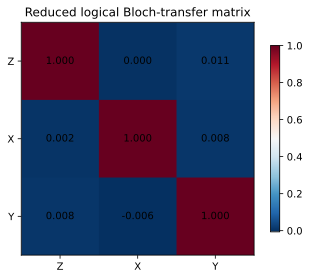

In [8]:
_plot_matrix(
    tomo_results["reduced_bloch_transfer"],
    title="Reduced logical Bloch-transfer matrix",
    row_labels=tomo_results["measurement_axes"],
    col_labels=tomo_results["prep_axes"],
)


## 4. Cycle-level effective logical noise models

Here we estimate a small Markov model for a repeated logical cycle by measuring the transition probabilities between logical 0 and logical 1 after increasingly deep identity-preserving logical subcircuits.


In [9]:
def cycle_level_transition_models(
    decoder_ctor: DecoderCtor = BpOsdDecoder,
    shots: int = 4000,
) -> dict[int, npt.NDArray[np.float64]]:
    zero_kernels = {
        1: cycle_zero_depth_1,
        2: cycle_zero_depth_2,
        4: cycle_zero_depth_4,
    }
    one_kernels = {
        1: cycle_one_depth_1,
        2: cycle_one_depth_2,
        4: cycle_one_depth_4,
    }

    models: dict[int, npt.NDArray[np.float64]] = {}
    for depth in zero_kernels:
        task0, _, detectors0, observables0 = _run_task(zero_kernels[depth], shots, with_noise=True)
        target0 = _reference_target(task0, zero_kernels[depth])
        _, corrected0 = _decode_observables(task0, detectors0, observables0, decoder_ctor)
        p00 = float(np.mean(np.all(corrected0 == target0, axis=1)))
        p01 = 1.0 - p00

        task1, _, detectors1, observables1 = _run_task(one_kernels[depth], shots, with_noise=True)
        target1 = _reference_target(task1, one_kernels[depth])
        _, corrected1 = _decode_observables(task1, detectors1, observables1, decoder_ctor)
        p11 = float(np.mean(np.all(corrected1 == target1, axis=1)))
        p10 = 1.0 - p11

        models[depth] = np.asarray([[p00, p01], [p10, p11]], dtype=float)

    return models


cycle_models = cycle_level_transition_models()
cycle_models


{1: array([[1., 0.],
        [0., 1.]]),
 2: array([[1.     , 0.     ],
        [0.00025, 0.99975]]),
 4: array([[1., 0.],
        [0., 1.]])}

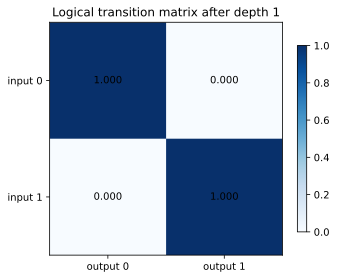

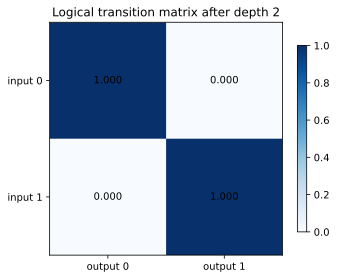

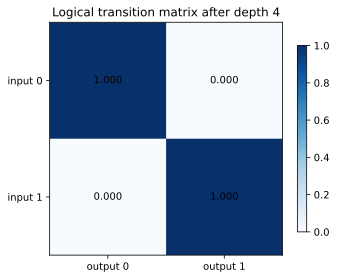

In [10]:
for depth, matrix in cycle_models.items():
    _plot_matrix(
        matrix,
        title=f"Logical transition matrix after depth {depth}",
        row_labels=["input 0", "input 1"],
        col_labels=["output 0", "output 1"],
        cmap="Blues",
    )


## 5. Syndrome-conditioned analysis

This is often the most useful debug view after decode-first metrology: bucket shots by detector weight (or by specific detector patterns) and ask how the logical failure rate changes with syndrome evidence.


In [11]:
def syndrome_conditioned_analysis(
    kernel=z_memory_probe,
    decoder_ctor: DecoderCtor = BpOsdDecoder,
    shots: int = 4000,
) -> dict[str, Any]:
    task, _, detectors, observables = _run_task(kernel, shots, with_noise=True)
    target = _reference_target(task, kernel)
    _, corrected = _decode_observables(task, detectors, observables, decoder_ctor)
    target_rows = np.broadcast_to(target, corrected.shape)
    failures = np.any(corrected != target_rows, axis=1)
    weights = np.sum(detectors, axis=1)

    error_rate_by_weight: dict[int, float] = {}
    count_by_weight: dict[int, int] = {}
    for weight in sorted(set(map(int, weights.tolist()))):
        mask = weights == weight
        error_rate_by_weight[weight] = float(np.mean(failures[mask]))
        count_by_weight[weight] = int(np.sum(mask))

    top_patterns = Counter(map(lambda row: tuple(map(int, row)), detectors.tolist())).most_common(10)
    return {
        "error_rate_by_detector_weight": error_rate_by_weight,
        "count_by_detector_weight": count_by_weight,
        "top_detector_patterns": top_patterns,
    }


syndrome_results = syndrome_conditioned_analysis()
syndrome_results


{'error_rate_by_detector_weight': {0: 0.0},
 'count_by_detector_weight': {0: 4000},
 'top_detector_patterns': [((0, 0, 0), 4000)]}

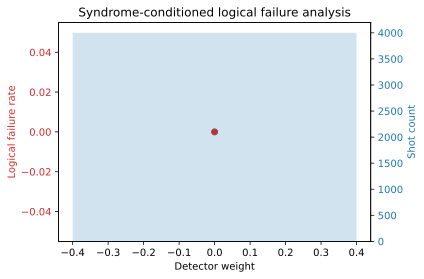

In [12]:
weights = list(syndrome_results["error_rate_by_detector_weight"].keys())
rates = [syndrome_results["error_rate_by_detector_weight"][w] for w in weights]
counts = [syndrome_results["count_by_detector_weight"][w] for w in weights]

fig, ax1 = plt.subplots(figsize=(6, 4))
ax1.plot(weights, rates, marker="o", color="tab:red")
ax1.set_xlabel("Detector weight")
ax1.set_ylabel("Logical failure rate", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:red")

ax2 = ax1.twinx()
ax2.bar(weights, counts, alpha=0.2, color="tab:blue")
ax2.set_ylabel("Shot count", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")
plt.title("Syndrome-conditioned logical failure analysis")
plt.tight_layout()
plt.show()


## 6. Model-fitting / learning-style analysis

This is a simple learning-style baseline: fit a small predictive model from syndrome-derived features to logical failure. It is intentionally lightweight and interpretable.


In [13]:
def fit_logical_failure_model(
    kernel=z_memory_probe,
    decoder_ctor: DecoderCtor = BpOsdDecoder,
    shots: int = 4000,
) -> dict[str, Any]:
    task, _, detectors, observables = _run_task(kernel, shots, with_noise=True)
    target = _reference_target(task, kernel)
    _, corrected = _decode_observables(task, detectors, observables, decoder_ctor)
    target_rows = np.broadcast_to(target, corrected.shape)
    failures = np.any(corrected != target_rows, axis=1).astype(float)

    detector_weight = np.sum(detectors, axis=1).astype(float)
    max_detector = np.max(detectors, axis=1).astype(float)
    X = np.column_stack([np.ones(len(detector_weight)), detector_weight, max_detector])
    beta, *_ = np.linalg.lstsq(X, failures, rcond=None)
    predicted = np.clip(X @ beta, 0.0, 1.0)
    mse = float(np.mean((predicted - failures) ** 2))

    return {
        "coefficients": {
            "bias": float(beta[0]),
            "detector_weight": float(beta[1]),
            "has_any_detector_click": float(beta[2]),
        },
        "mse": mse,
        "predicted_failure_probability": predicted,
        "observed_failure_indicator": failures,
        "detector_weight": detector_weight,
    }


fit_results = fit_logical_failure_model()
fit_results["coefficients"], fit_results["mse"]


/var/folders/4t/_g5ztpl96sg8j3_ztt9wgc400000gp/T/ipykernel_1918/3692404175.py:16: RuntimeWarning: divide by zero encountered in matmul
  predicted = np.clip(X @ beta, 0.0, 1.0)
/var/folders/4t/_g5ztpl96sg8j3_ztt9wgc400000gp/T/ipykernel_1918/3692404175.py:16: RuntimeWarning: overflow encountered in matmul
  predicted = np.clip(X @ beta, 0.0, 1.0)
/var/folders/4t/_g5ztpl96sg8j3_ztt9wgc400000gp/T/ipykernel_1918/3692404175.py:16: RuntimeWarning: invalid value encountered in matmul
  predicted = np.clip(X @ beta, 0.0, 1.0)


({'bias': 0.0, 'detector_weight': 0.0, 'has_any_detector_click': 0.0}, 0.0)

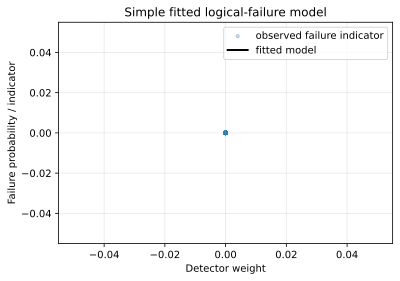

In [14]:
plt.figure(figsize=(6, 4))
plt.scatter(
    fit_results["detector_weight"],
    fit_results["observed_failure_indicator"],
    s=12,
    alpha=0.25,
    label="observed failure indicator",
)
order = np.argsort(fit_results["detector_weight"])
plt.plot(
    fit_results["detector_weight"][order],
    fit_results["predicted_failure_probability"][order],
    color="black",
    linewidth=2,
    label="fitted model",
)
plt.xlabel("Detector weight")
plt.ylabel("Failure probability / indicator")
plt.title("Simple fitted logical-failure model")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
